# Egg Classifier


### Libraries needed

In [84]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
)
import cv2
import random
import pandas as pd
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

## Configuration


In [85]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [86]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [87]:
IMG_SIZE = (180, 180)
BATCH_SIZE = 16

Directory set up


In [88]:
DATA_DIR = "Eggs_Classification"
DAMAGED_DIR = os.path.join(DATA_DIR, "Damaged")
NOT_DAMAGED_DIR = os.path.join(DATA_DIR, "Not_Damaged")

In [89]:
print("Egg Classification Model Training")
print(f"Damaged images directory: {DAMAGED_DIR}")
print(f"Not damaged images directory: {NOT_DAMAGED_DIR}")

Egg Classification Model Training
Damaged images directory: Eggs_Classification\Damaged
Not damaged images directory: Eggs_Classification\Not_Damaged


## Data Loading & Preprocessing


### Data Loading


In [90]:
def load_images_from_directory(directory, label):
    """
    Load all images from a directory and assign them a label

    Returns:
      A list of tuples (image_array, label)
    """

    images, img_paths = [], []
    labels = []

    valid_extensions = [".jpg", ".jpeg", ".png"]
    files = [
        f
        for f in os.listdir(directory)
        if os.path.splitext(f.lower())[1] in valid_extensions
    ]

    print(f"Found {len(files)} images in {directory}")
    for filename in files:
        file_path = os.path.join(directory, filename)

        try:
            # Load and preprocess images
            img = cv2.imread(file_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            brightness = np.mean(img)
            if brightness < 50:
                dark_image_count += 1
                gamma = 1.5

                img = np.clip(((img / 255.0) ** (1 / gamma)) * 255.0, 0, 255).astype(
                    np.uint8
                )

            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0

            images.append(img)
            img_paths.append(file_path)
            labels.append(label)

        except Exception as e:
            print(f"Error loading image {file_path}: {e}")

    return images, img_paths, labels

Load damaged and not damaged images


In [91]:
damaged_images, damaged_paths, damaged_labels = load_images_from_directory(
    DAMAGED_DIR, 1
)

Found 632 images in Eggs_Classification\Damaged


In [92]:
not_damaged_images, not_damaged_paths, not_damaged_labels = load_images_from_directory(
    NOT_DAMAGED_DIR, 0
)

Found 631 images in Eggs_Classification\Not_Damaged


Combine datasets


In [93]:
all_images = damaged_images + not_damaged_images
all_paths = damaged_paths + not_damaged_paths
all_labels = damaged_labels + not_damaged_labels

In [94]:
X = np.array(all_images)
y = np.array(all_labels)

In [95]:
print(f"Total dataset size: {len(X)} images")
print(f"Damaged eggs: {len(damaged_images)}")
print(f"Undamaged eggs: {len(not_damaged_images)}")

Total dataset size: 1263 images
Damaged eggs: 632
Undamaged eggs: 631


Sample images


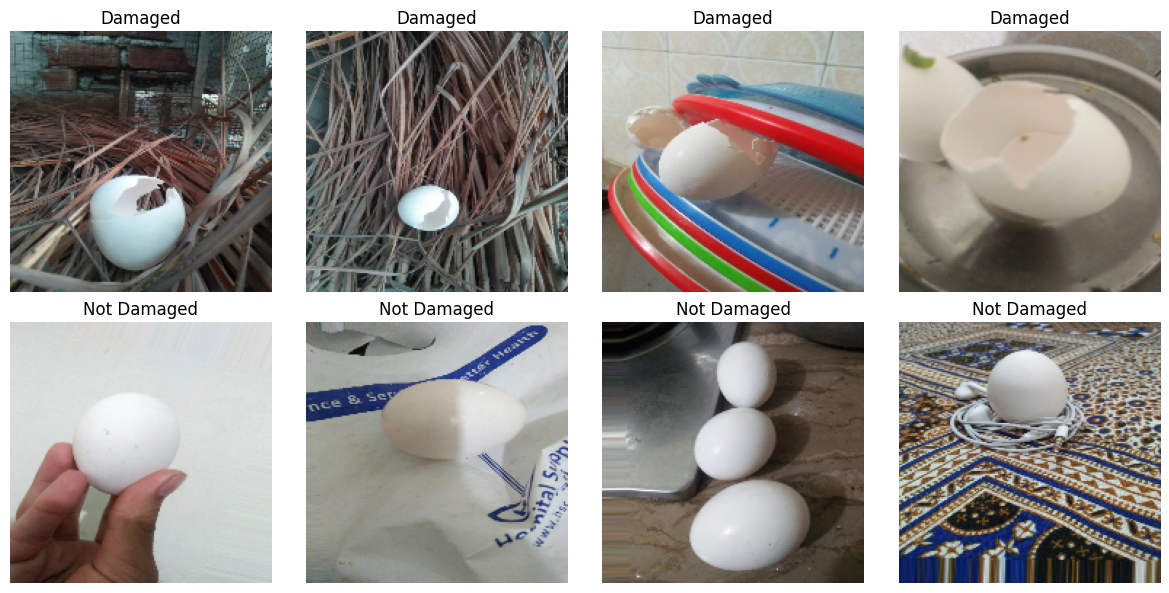

In [96]:
plt.figure(figsize=(12, 6))

for i in range(min(8, len(all_images))):
    plt.subplot(2, 4, i + 1)

    idx = i if i < 4 else i + len(all_images) - 8
    img = all_images[idx]
    label = "Damaged" if all_labels[idx] == 1 else "Not Damaged"

    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Split

Train and test separation


In [97]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

Validation and training segments


In [98]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=42, stratify=y_train_val
)

In [99]:
print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")

Training set: 912 images
Validation set: 161 images
Test set: 190 images


In [100]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)

### Contrast


In [101]:
def improve_image_quality(images):
    """Apply simple but effective image enhancement techniques"""
    improved = []

    for img in images:
        img_255 = (img * 255).astype(np.uint8)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab = cv2.cvtColor(img_255, cv2.COLOR_RGB2Lab)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])

        enhanced = cv2.cvtColor(lab, cv2.COLOR_Lab2RGB)
        enhanced = enhanced.astype(np.float32) / 255.0

        improved.append(enhanced)

    return np.array(improved)

In [102]:
X_train_enhanced = improve_image_quality(X_train)
X_val_enhanced = improve_image_quality(X_val)
X_test_enhanced = improve_image_quality(X_test)

In [103]:
def show_enhancement_comparison(original_images, enhanced_images, indices=None, n=3):
    if indices is None:
        indices = np.random.choice(len(original_images), size=n)

    plt.figure(figsize=(12, 4 * n))
    for i, idx in enumerate(indices):
        # Original
        plt.subplot(n, 2, i * 2 + 1)
        plt.imshow(original_images[idx])
        plt.title(f"Original (Image {idx})")
        plt.axis("off")

        # Enhanced
        plt.subplot(n, 2, i * 2 + 2)
        plt.imshow(enhanced_images[idx])
        plt.title(f"Enhanced (Image {idx})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

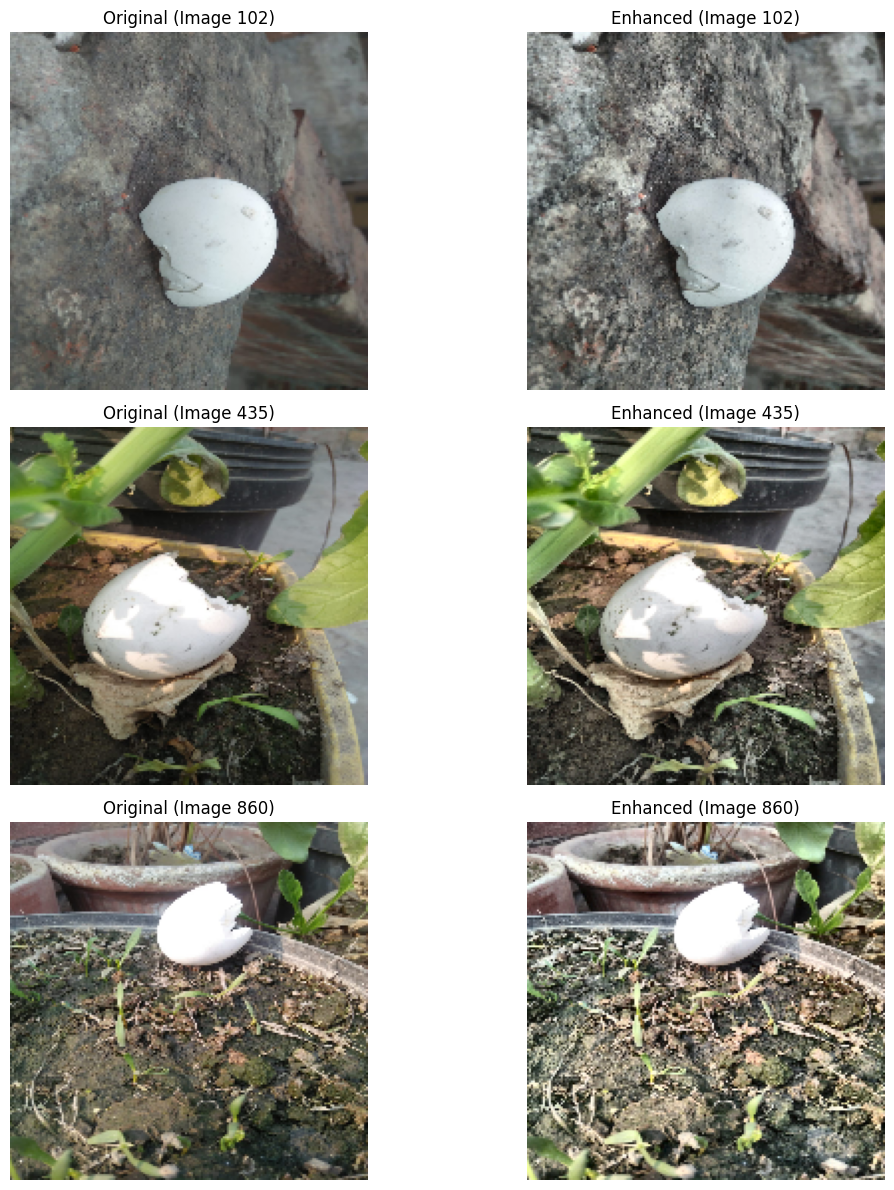

In [104]:
show_enhancement_comparison(X_train, X_train_enhanced)

### Data Augmentation


In [105]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode="nearest",
)

In [106]:
def visualize_augmentation(X_sample, y_sample, n_images=5):
    idxs = np.random.choice(range(len(X_sample)), n_images, replace=False)
    X_temp = X_sample[idxs]
    y_temp = y_sample[idxs]

    plt.figure(figsize=(15, 3 * n_images))
    for i in range(n_images):
        plt.subplot(n_images, 5, i * 5 + 1)
        plt.imshow(X_temp[i])
        plt.title(f"Original: {'Damaged' if y_temp[i]==1 else 'Not Damaged'}")
        plt.axis("off")

        for j in range(4):
            plt.subplot(n_images, 5, i * 5 + j + 2)
            aug_img = next(datagen.flow(X_temp[i : i + 1], batch_size=1))[0]
            plt.imshow(aug_img)
            plt.title(f"Augmented {j+1}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

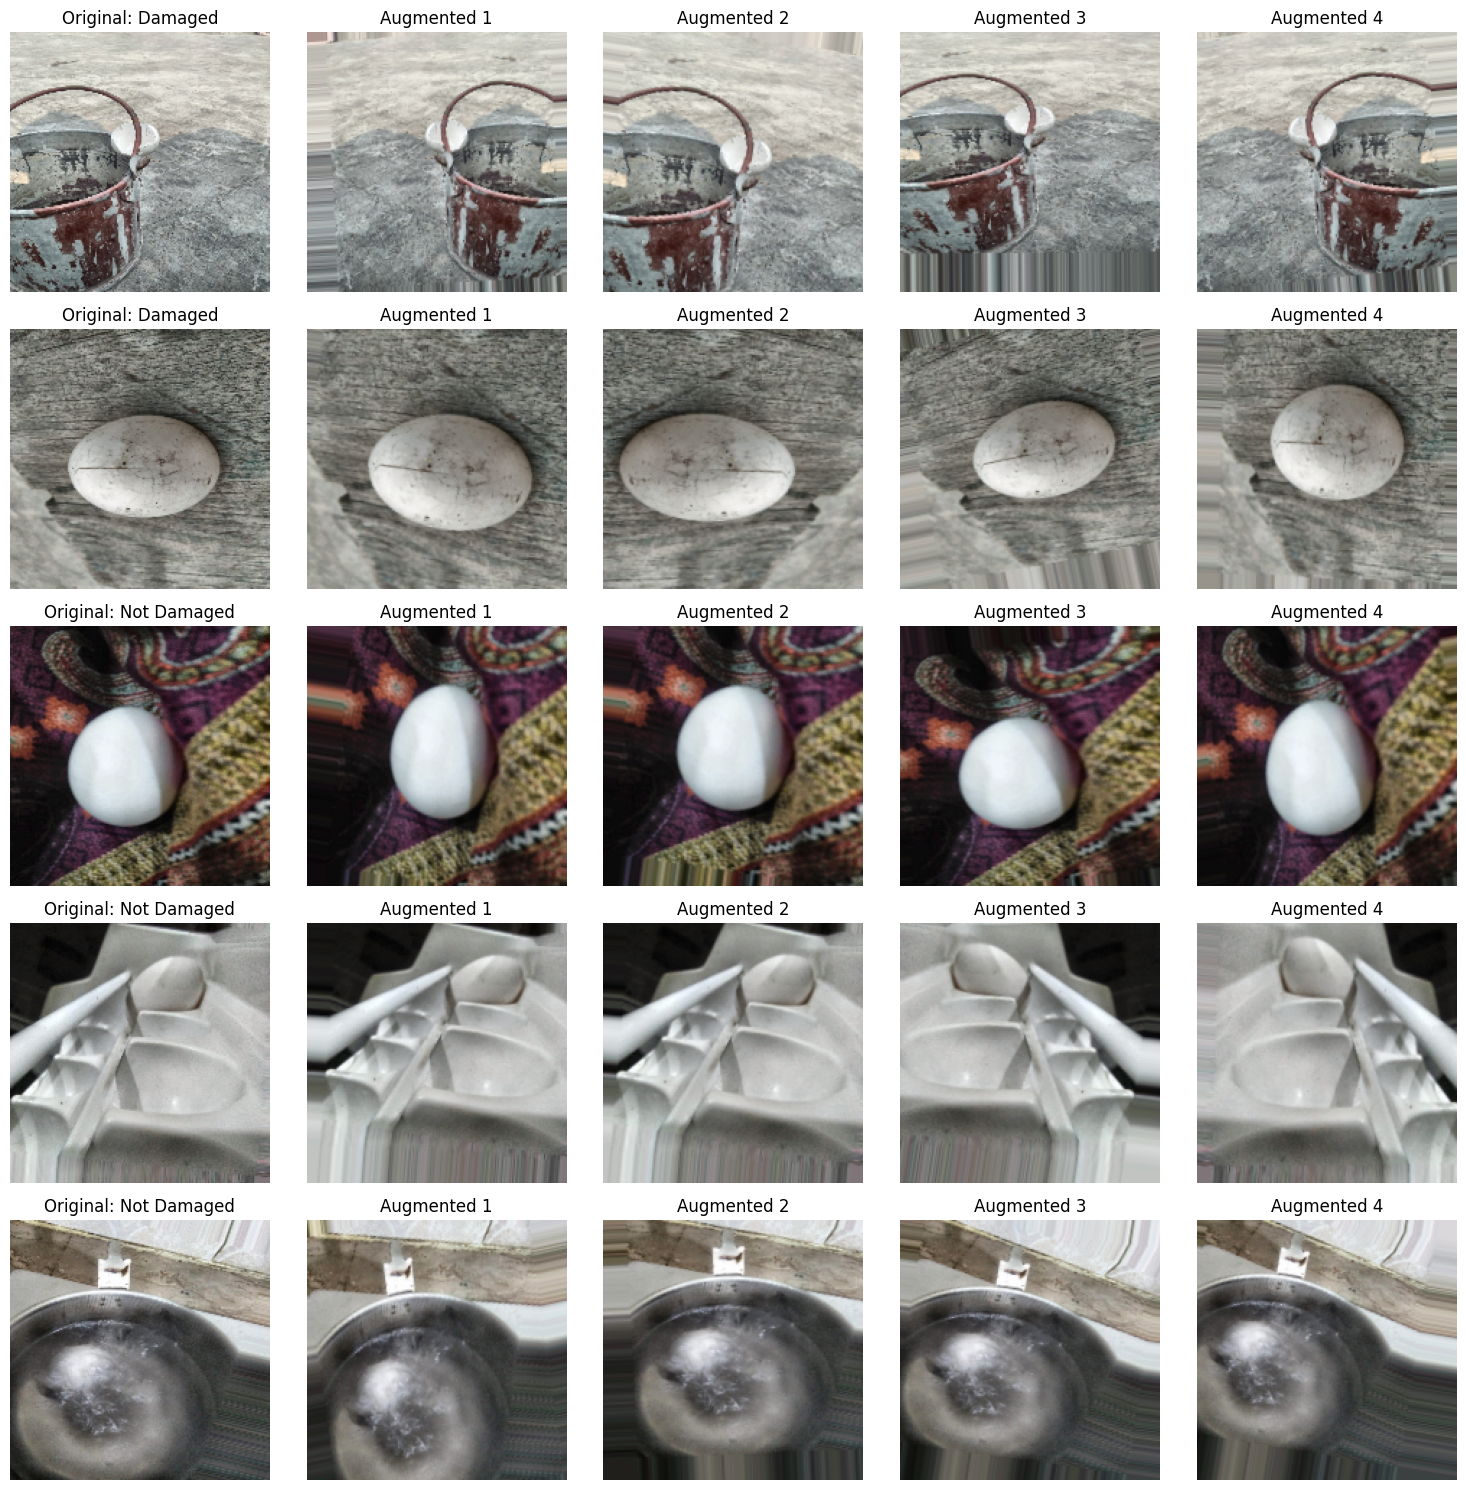

In [107]:
visualize_augmentation(X_train_enhanced, y_train)

## Model Creation


In [108]:
def create_model(input_shape):
    """
    Creates a model with less capacity to overfit
    """
    model = Sequential(
        [
            # First convolutional block - focus on detailed features
            Conv2D(
                32, (3, 3), activation="relu", padding="same", input_shape=input_shape
            ),
            Conv2D(
                32, (3, 3), activation="relu", padding="same"
            ),  
            MaxPooling2D(pool_size=(2, 2)),

            # Second convolutional block
            Conv2D(64, (3, 3), activation="relu", padding="same"),
            MaxPooling2D(pool_size=(2, 2)),

            # Third convolutional block
            Conv2D(128, (3, 3), activation="relu", padding="same"),
            MaxPooling2D(pool_size=(2, 2)),
            
            # Flatten and dense layers
            Flatten(),
            Dense(128, activation="relu"),
            Dropout(0.35),
            Dense(
                1,
                activation="sigmoid",
                bias_initializer=tf.keras.initializers.Constant(0.3),
            ),
        ]
    )

    # Standard Adam optimizer
    model.compile(
        optimizer=Adam(learning_rate=2e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model

In [109]:
model = create_model((*IMG_SIZE, 3))
model.summary()

c:\Users\diego\miniconda3\envs\tf-cpu1\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,032,609 (30.64 MB)

 Trainable params: 8,032,609 (30.64 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
checkpoint_path = "best_model.keras"

In [111]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.6,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1
    ),
]

In [112]:
y_labels = np.unique(y_train)
class_counts = [np.sum(y_train == label) for label in y_labels]
n_samples = len(y_train)
n_classes = len(y_labels)

In [113]:
class_weight_dict = {
    label: n_samples / (n_classes * count) * 0.5 + 0.5
    for label, count in zip(y_labels, class_counts)
}

print(f"Moderated class weights: {class_weight_dict}")

Moderated class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [114]:
class_weight_dict = {
    0: 1.7,  # Higher weight for Not Damaged class
    1: 1.0,  # Normal weight for Damaged class
}

## Model Training


In [115]:
history = model.fit(
    datagen.flow(X_train_enhanced, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train_enhanced) // BATCH_SIZE,
    validation_data=(X_val_enhanced, y_val),
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1,
)

c:\Users\diego\miniconda3\envs\tf-cpu1\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5364 - auc: 0.5030 - loss: 0.9071 - precision: 0.5659 - recall: 0.1370
Epoch 1: val_loss improved from inf to 0.72903, saving model to best_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.5367 - auc: 0.5045 - loss: 0.9065 - precision: 0.5676 - recall: 0.1383 - val_accuracy: 0.5652 - val_auc: 0.5845 - val_loss: 0.7290 - val_precision: 0.6341 - val_recall: 0.3210 - learning_rate: 2.0000e-04
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6285 - auc: 0.7358 - loss: 0.7734 - precision: 0.7023 - recall: 0.4100
Epoch 2: val_loss did not improve from 0.72903
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.6295 - auc: 0.7367 - loss: 0.7726 - precision: 0.7037 - recall: 0.4118 - val_accuracy: 0.5776 - val_auc: 0.6067 - val_loss: 1.0850 - val_precision: 0.7407 - val_recall: 0.2469 - learning_rate: 2.0000e-04
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7260 - auc: 

## History Plots


In [116]:
def plot_training_history(history):
    metrics = ["accuracy", "loss", "precision", "recall"]
    plt.figure(figsize=(15, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i + 1)
        plt.plot(history.history[metric])
        plt.plot(history.history[f"val_{metric}"])
        plt.title(f"Model {metric}")
        plt.ylabel(metric)
        plt.xlabel("Epoch")
        plt.legend(["Train", "Validation"], loc="best")

    plt.tight_layout()
    plt.show()

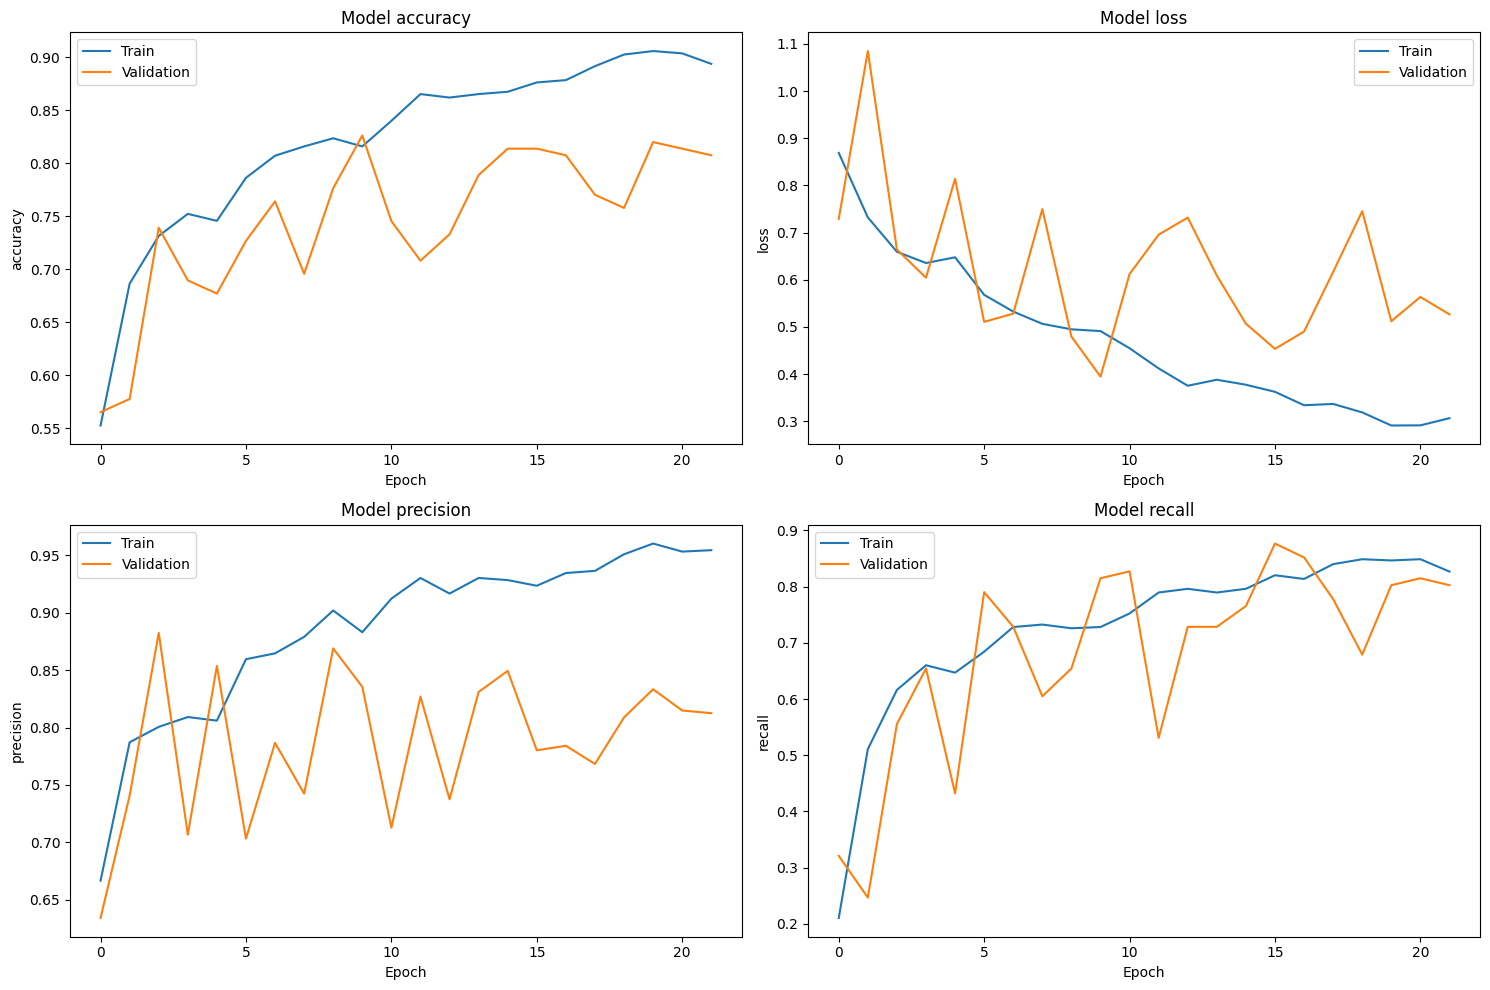

In [117]:
plot_training_history(history)

## Evaluating the Model


In [118]:
val_preds = model.predict(X_val_enhanced)
precisions, recalls, thresholds = precision_recall_curve(y_val, val_preds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step


In [119]:
f1_scores = (
    2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-7)
)

In [120]:
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1 score on validation: {best_f1:.4f}")

Optimal threshold: 0.5332
Best F1 score on validation: 0.8354


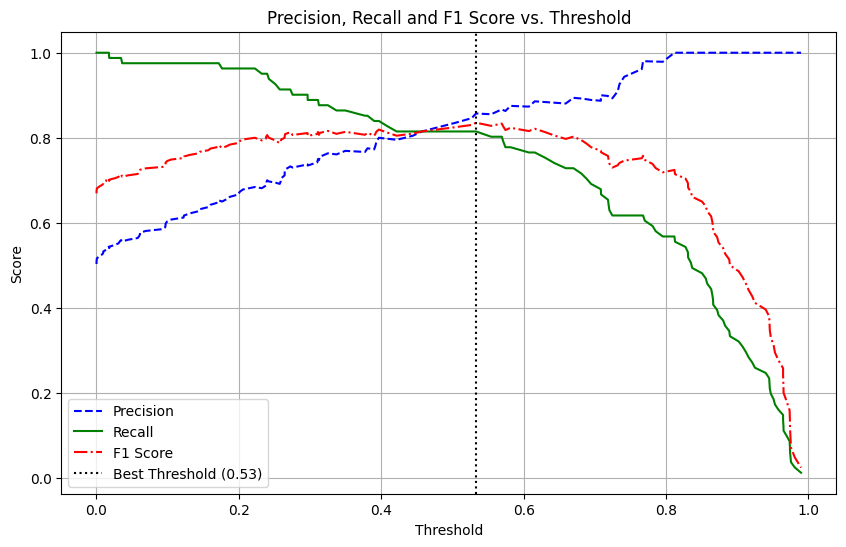

In [121]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.plot(thresholds, f1_scores, "r-.", label="F1 Score")
plt.axvline(
    x=best_threshold,
    color="k",
    linestyle=":",
    label=f"Best Threshold ({best_threshold:.2f})",
)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()

## Evaluate on Test Set


In [122]:
test_metrics = model.evaluate(X_test_enhanced, y_test, verbose=1)
metric_names = ["loss", "accuracy", "precision", "recall", "auc"]

print("\nDefault Threshold Metrics:")
for name, value in zip(metric_names, test_metrics):
    print(f"Test {name}: {value:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.8504 - auc: 0.9408 - loss: 0.3190 - precision: 0.8509 - recall: 0.8270

Default Threshold Metrics:
Test loss: 0.3655
Test accuracy: 0.8263
Test precision: 0.8523
Test recall: 0.7895
Test auc: 0.9184


In [123]:
y_pred_prob = model.predict(X_test_enhanced)
y_pred = (y_pred_prob > best_threshold).astype(int)

# Calculate F1 score with optimal threshold
f1 = f1_score(y_test, y_pred)
print(f"\nOptimal Threshold Metrics:")
print(f"F1 Score: {f1:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step

Optimal Threshold Metrics:
F1 Score: 0.8132


In [124]:
print(classification_report(y_test, y_pred, target_names=["Not Damaged", "Damaged"]))

              precision    recall  f1-score   support

 Not Damaged       0.80      0.86      0.83        95
     Damaged       0.85      0.78      0.81        95

    accuracy                           0.82       190
   macro avg       0.82      0.82      0.82       190
weighted avg       0.82      0.82      0.82       190



In [125]:
def plot_confusion_matrix(y_true, y_pred, class_names=["Not Damaged", "Damaged"]):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    # Also show percentages
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix")
    plt.show()

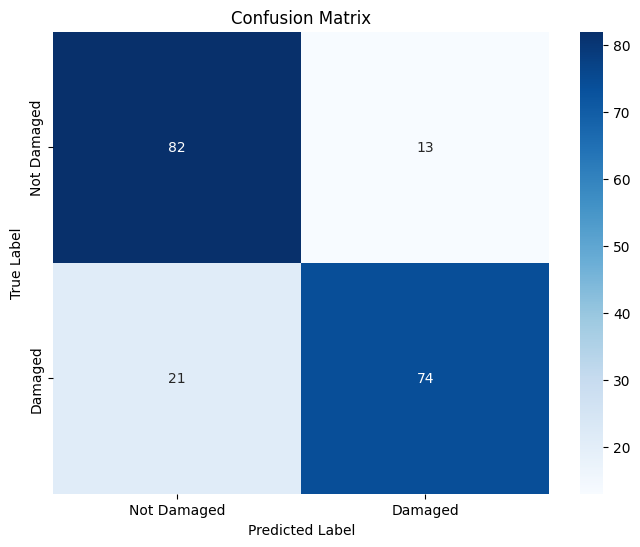

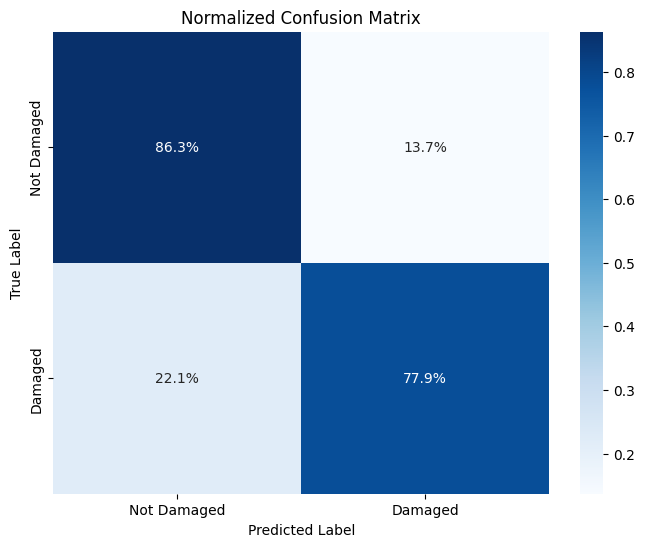

In [126]:
plot_confusion_matrix(y_test, y_pred)

In [127]:
def plot_predictions(X, y_true, y_pred, y_prob, n_samples=10):
    correct_idx = np.where(y_true == y_pred)[0]
    incorrect_idx = np.where(y_true != y_pred)[0]
    n_correct = min(n_samples // 2, len(correct_idx))
    n_incorrect = min(n_samples - n_correct, len(incorrect_idx))

    selected_correct = np.random.choice(correct_idx, n_correct, replace=False)
    selected_incorrect = np.random.choice(incorrect_idx, n_incorrect, replace=False)
    indices = np.concatenate([selected_correct, selected_incorrect])
    np.random.shuffle(indices)

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(indices[:n_samples]):
        plt.subplot(2, n_samples // 2, i + 1)
        plt.imshow(X[idx])

        true_label = "Damaged" if y_true[idx] == 1 else "Not Damaged"
        pred_label = "Damaged" if y_pred[idx] == 1 else "Not Damaged"
        pred_prob = y_prob[idx][0]

        title_color = "green" if y_true[idx] == y_pred[idx] else "red"
        confidence = pred_prob if y_pred[idx] == 1 else 1 - pred_prob
        title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}"

        plt.title(title, color=title_color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

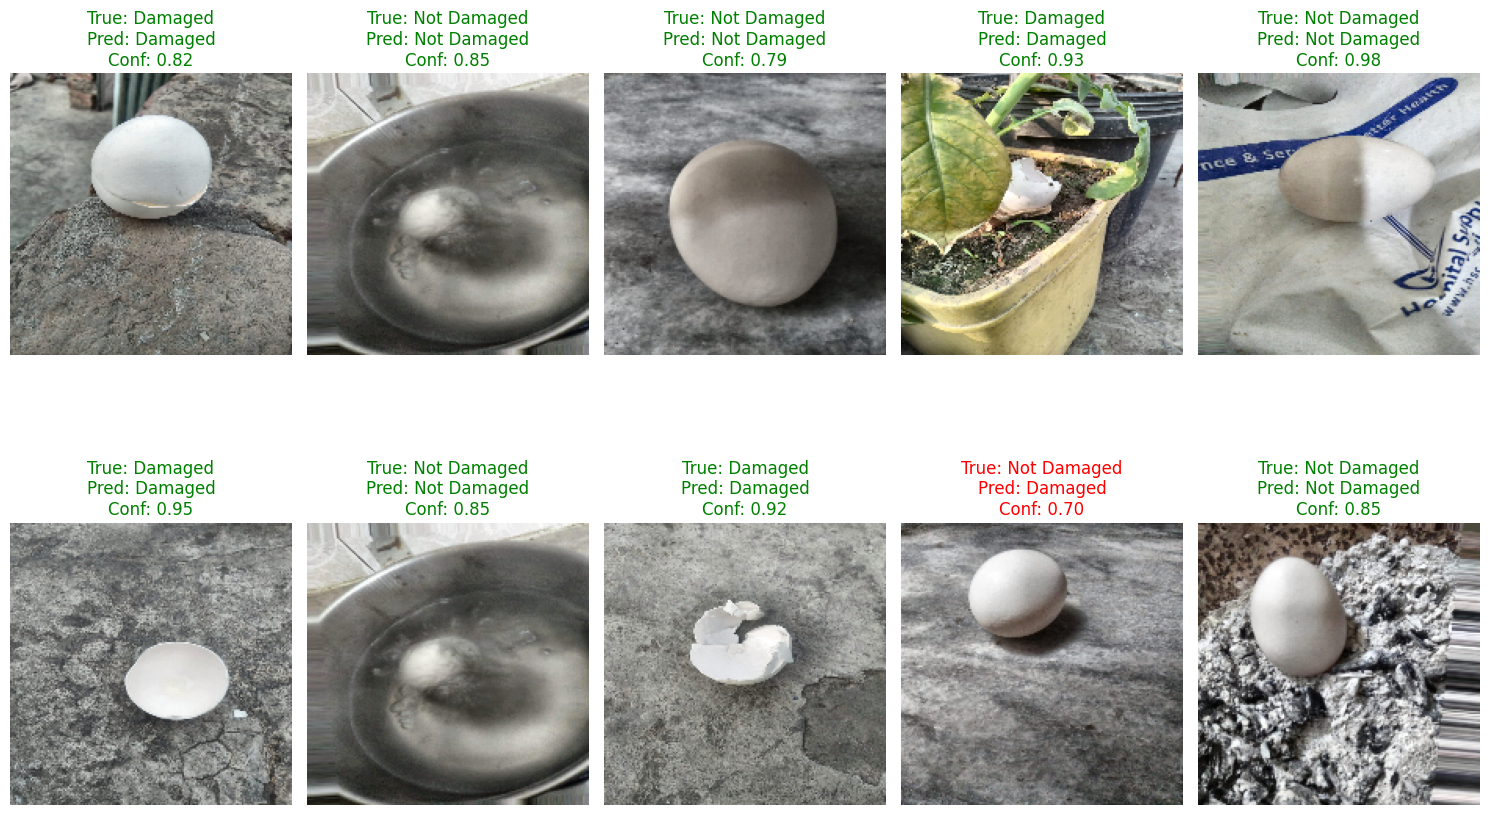

In [128]:
plot_predictions(X_test_enhanced, y_test, y_pred, y_pred_prob)

In [129]:
def preprocess_image(image_path):
    # Load and preprocess images
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    brightness = np.mean(img)
    if brightness < 50:
        dark_image_count += 1
        gamma = 1.5

        img = np.clip(((img / 255.0) ** (1 / gamma)) * 255.0, 0, 255).astype(
            np.uint8
        )

    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    return img

In [130]:
from pathlib import Path

In [135]:
test_path = Path("./test.jpg")
if test_path.exists():
    test_image = preprocess_image(str(test_path))
    test_image = np.expand_dims(test_image, axis=0)

    pred_prob = model.predict(test_image)
    pred_label = (pred_prob > best_threshold).astype(int)[0][0]

    print(f"Predicted label for {test_path.name}: {'Damaged' if pred_label == 1 else 'Not Damaged'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted label for test.jpg: Damaged
